In [14]:
import os
BASE_DIR = os.path.abspath(os.path.join(os.path.dirname("."), ".."))
EXPORTS_DIR = f"{BASE_DIR}/_exports/02_02_trustworthiness_assessment"
os.makedirs(EXPORTS_DIR, exist_ok=True)

In [5]:
# load Basins
import pickle
from lilypond.basin import Basin
# dataset_names = ['Moon', 'S-Curve', 'Swiss Roll', 'Iris', 'Glass', 'Mushroom', 'Cardio'] # FIXME
dataset_names = ['Moon', 'S-Curve', 'Swiss Roll', 'Iris', 'Glass', 'Mushroom', 'Cardio']
basins = []
for dataset_name in dataset_names:
	basin:Basin = pickle.load(open(f"./_exports/basin_{dataset_name}.pkl", 'rb'))
	basins.append(basin)

In [6]:
# caclulate trustworthiness across varying k neighborhood setting
import numpy as np
import pandas as pd
from _utils.som_evaluation import calc_som_trustworthiness_umatrix, calc_som_trustworthiness_umatrix_altered

k_candidates = np.arange(5, 50+1, 5)
df_trustworthiness = pd.DataFrame(
    columns=k_candidates,
    index=pd.MultiIndex.from_product([dataset_names, ["M_baseline", "M_altered"]], names=["dataset", "metric"])
)

for dataset_name, basin in zip(dataset_names, basins):
	for k in k_candidates:
		print(dataset_name, k)
		df_trustworthiness.loc[(dataset_name, "M_baseline"), k] = calc_som_trustworthiness_umatrix(basin.som, basin.data, k)
		df_trustworthiness.loc[(dataset_name, "M_altered"), k] = calc_som_trustworthiness_umatrix_altered(basin.som, basin.data, k)

Moon 5
Moon 10
Moon 15
Moon 20
Moon 25
Moon 30
Moon 35
Moon 40
Moon 45
Moon 50
S-Curve 5
S-Curve 10
S-Curve 15
S-Curve 20
S-Curve 25
S-Curve 30
S-Curve 35
S-Curve 40
S-Curve 45
S-Curve 50
Swiss Roll 5
Swiss Roll 10
Swiss Roll 15
Swiss Roll 20
Swiss Roll 25
Swiss Roll 30
Swiss Roll 35
Swiss Roll 40
Swiss Roll 45
Swiss Roll 50
Iris 5
Iris 10
Iris 15
Iris 20
Iris 25
Iris 30
Iris 35
Iris 40
Iris 45
Iris 50
Glass 5
Glass 10
Glass 15
Glass 20
Glass 25
Glass 30
Glass 35
Glass 40
Glass 45
Glass 50
Mushroom 5
Mushroom 10
Mushroom 15
Mushroom 20
Mushroom 25
Mushroom 30
Mushroom 35
Mushroom 40
Mushroom 45
Mushroom 50
Cardio 5
Cardio 10
Cardio 15
Cardio 20
Cardio 25
Cardio 30
Cardio 35
Cardio 40
Cardio 45
Cardio 50


In [ ]:
# df_trustworthiness.to_csv(f"./_exports/df_trustworthiness.csv", )

In [7]:
df_trustworthiness.style \
	.format(precision=4)

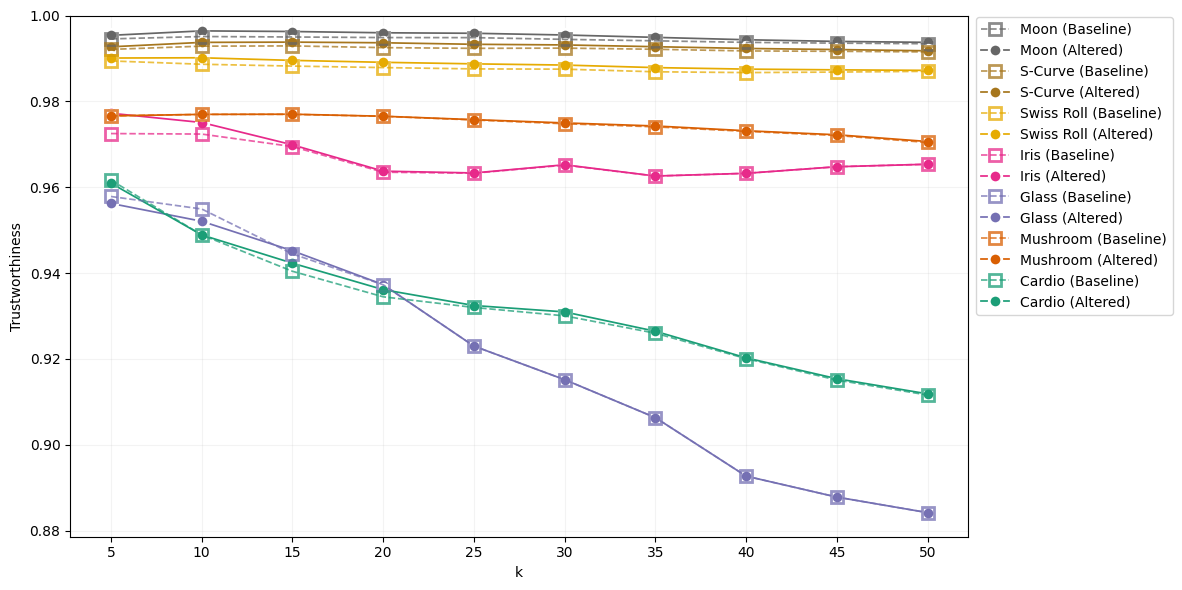

In [10]:
# plot trustworthiness chart
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(12, 6))
ax = plt.gca()

df_m_baseline = df_trustworthiness.xs("M_baseline", level='metric')
df_m_baseline.T.plot(kind='line', marker='s', markerfacecolor="none", markersize=9, markeredgewidth=2.0, linestyle="dashed", linewidth=1.25, cmap="Dark2_r", alpha=.75, zorder=3, ax=ax)

df_m_altered = df_trustworthiness.xs("M_altered", level='metric')
df_m_altered.T.plot(kind='line', marker='o', markersize=9, markeredgewidth=2.0, markeredgecolor="white", linestyle="solid", linewidth=1.25, cmap="Dark2_r", zorder=2, ax=ax)


ax.set_xlabel("k")
ax.set_ylabel("Trustworthiness")
plt.ylim(top=1.0)
plt.xticks(k_candidates)
plt.grid(alpha=.15)

handles, labels = ax.get_legend_handles_labels()
num_datasets = len(dataset_names)
handles_base = handles[:num_datasets]
handles_alt = handles[num_datasets:]
labels_base = labels[:num_datasets]
labels_alt = labels[num_datasets:]
new_handles = [h for pair in zip(handles_base, handles_alt) for h in pair]
new_labels = [l for pair in zip(list(map(lambda _: f"{_} (Baseline)",labels_base)), list(map(lambda _: f"{_} (Altered)", labels_alt))) for l in pair]
plt.legend(handles=new_handles, labels=new_labels, loc="upper right", bbox_to_anchor=(1.235, 1.01))
plt.tight_layout()
plt.show()

In [15]:
# export fig
from _utils.export import export_figure
export_figure(fig, EXPORTS_DIR, "02_02_trustworthiness_chart.png")

Figure saved to `_exports` folder as `02_02_trustworthiness_chart.png`
